# BANK CUSTOMER CHURN PREDICTION

In [111]:
#Importing the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [112]:
#loading the dataset
data_df=pd.read_csv('churn_modelling (1).csv')
data_df.shape

(10000, 14)

In [113]:
data_df.dtypes

,0
RowNumber,int64
CustomerId,int64
Surname,object
CreditScore,int64
Geography,object
Gender,object
Age,int64
Tenure,int64
Balance,float64
NumOfProducts,int64


In [114]:
data_df.head(10)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
5,6,15574012,Chu,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1
6,7,15592531,Bartlett,822,France,Male,50,7,0.00,2,1,1,10062.80,0
7,8,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
8,9,15792365,He,501,France,Male,44,4,142051.07,2,0,1,74940.50,0
9,10,15592389,H?,684,France,Male,27,2,134603.88,1,1,1,71725.73,0


In [115]:
data_df=data_df.drop(['RowNumber','CustomerId','Surname'],axis=1)
data_df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [116]:
data_df.isnull().sum()

,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0
HasCrCard,0
IsActiveMember,0
EstimatedSalary,0


In [117]:
data_df.nunique()

,0
CreditScore,460
Geography,3
Gender,2
Age,70
Tenure,11
Balance,6382
NumOfProducts,4
HasCrCard,2
IsActiveMember,2
EstimatedSalary,9999


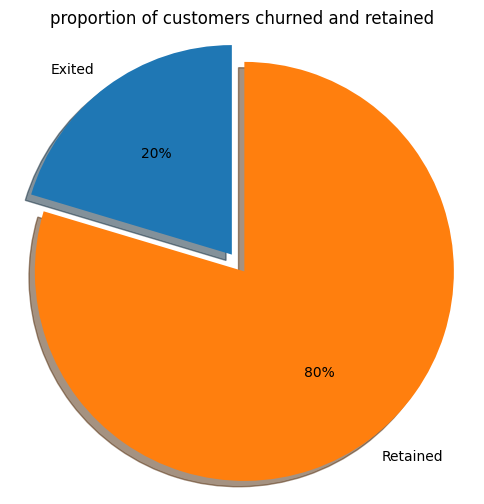

In [118]:
#plotting the pie chart to get the proportion of customers churned and retained(Univariate analysis)

labels=['Exited','Retained']
values=[data_df['Exited'].eq(1).sum(),data_df['Exited'].eq(0).sum()]
plt.figure(figsize=(6,6))
plt.pie(values,labels=labels,explode=[0,0.1],startangle=90,shadow=True,autopct='%1.0f%%')
plt.title("proportion of customers churned and retained")
plt.axis('equal')
plt.show()

20% of the customer have churned and remaining 80% haven't churned

In [119]:
data_df.columns

Index(['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited'],
      dtype='object')

In [120]:
list1=['Geography','Gender','HasCrCard','IsActiveMember']
list(enumerate(list1))

[(0, 'Geography'), (1, 'Gender'), (2, 'HasCrCard'), (3, 'IsActiveMember')]

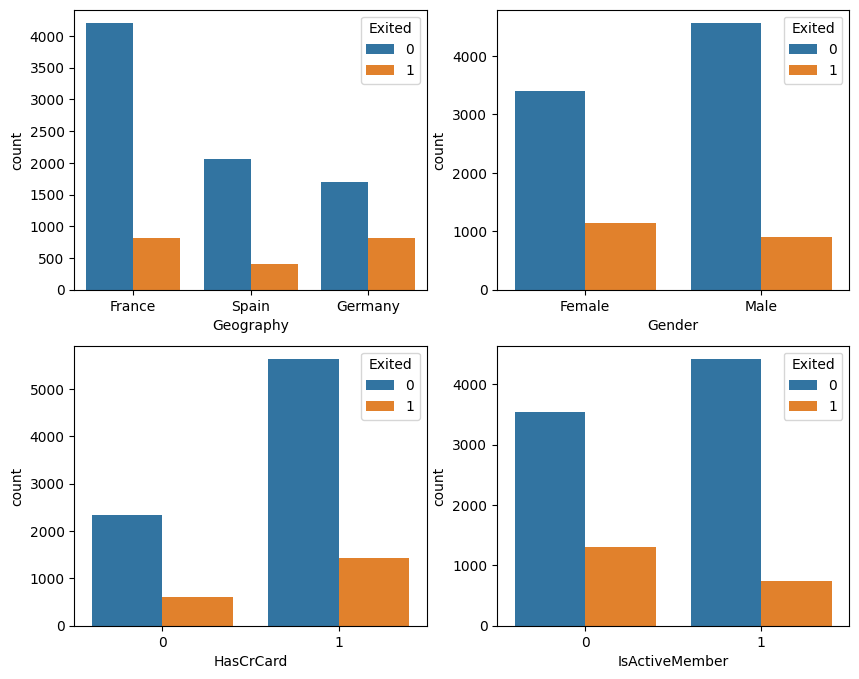

In [121]:
#plotting the categorical variables using histogram

plt.figure(figsize=(10,8))
for index,value in enumerate(list1):
  plt.subplot(2,2,index+1)#index+1 is used because subplot numbering starts from 1
  sns.countplot(x=value,hue='Exited',data=data_df)

# From the above plot we infer that

1.Most of the customers are from France and most of the customers churned are from Germany

2.The proportion of female customers churned is more than the male customers

3.Majority of the customers that churned are those with credit cards

4.The inactive members have a greater churn and the overall proportion of inactive members is also very high.

In [122]:
list2=['CreditScore','Age','Tenure','Balance','NumOfProducts','EstimatedSalary']
list(enumerate(list2))

[(0, 'CreditScore'),
 (1, 'Age'),
 (2, 'Tenure'),
 (3, 'Balance'),
 (4, 'NumOfProducts'),
 (5, 'EstimatedSalary')]

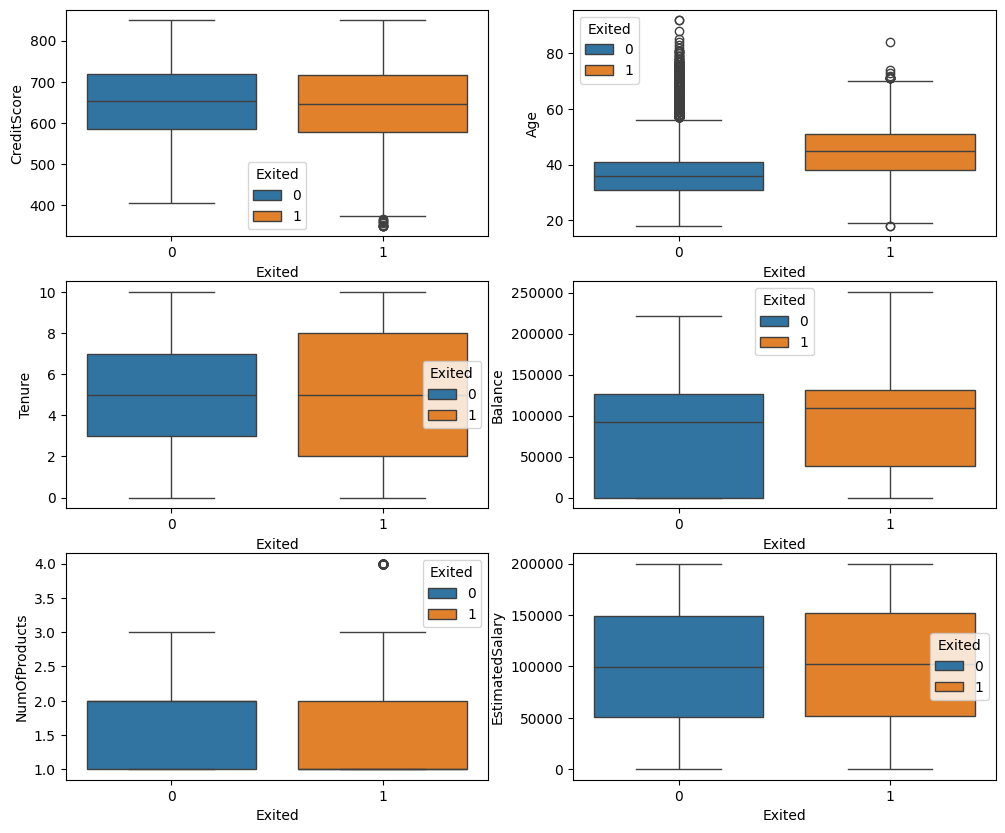

In [123]:
#plotting the categorical variables using boxplot
plt.figure(figsize=(12,10))
for index,value in enumerate(list2):
  plt.subplot(3,2,index+1)
  sns.boxplot(y=value,x='Exited',hue='Exited',data=data_df,order=[0,1])


# from the above plot we infer that

1.Credit score:There is no significant difference in the creditscore distribution between the retained and churned customer

2.Age:the older customers are churning more than the younger customers

3.Tenure:the customers who spent more time and less time with the bank are churned rather than the customers who have average tenure

4.Balance: the customers who have a significant bank balance have churned

5.numofproducts & salary : Both the product and salary does not have significant effect on the likelihood to churn

In [124]:
df_corr=data_df[['CreditScore','Age','Tenure','Balance','NumOfProducts','HasCrCard','IsActiveMember','EstimatedSalary','Exited']]


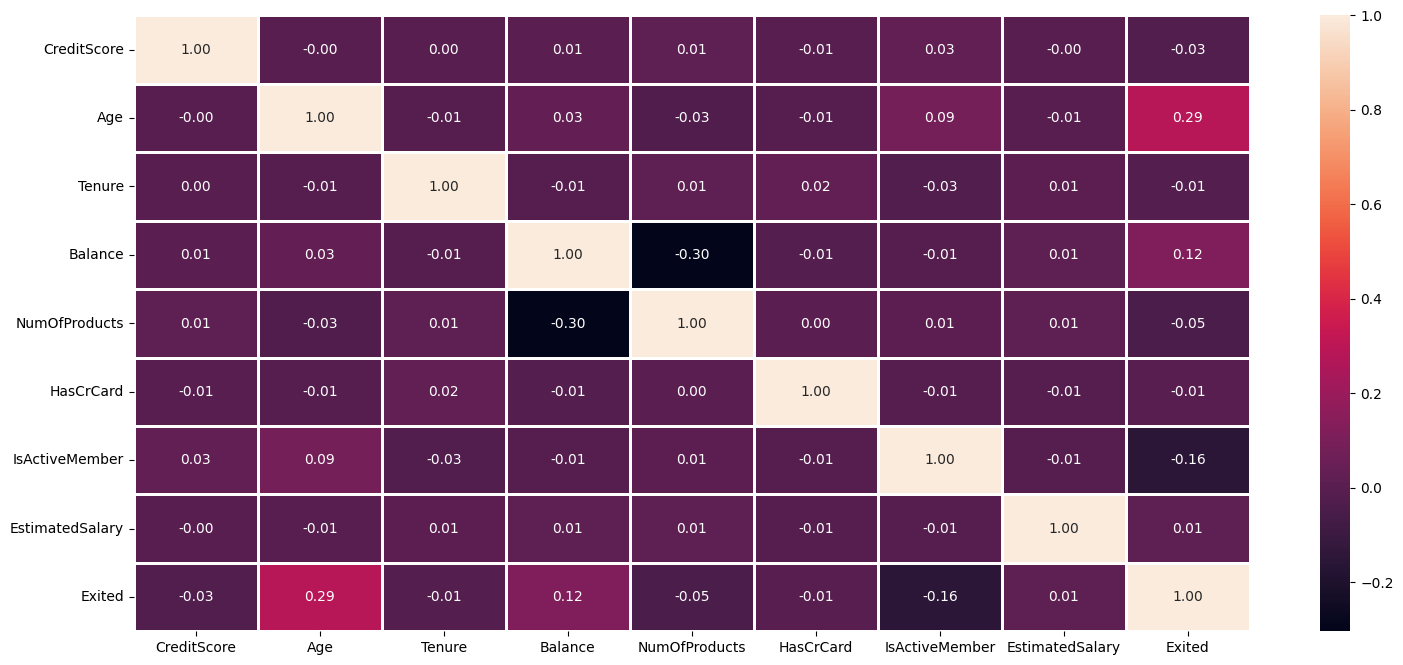

In [125]:
#Heatmap

plt.figure(figsize=(18,8))
corr=df_corr.corr()
sns.heatmap(corr,linewidths=1,annot=True,fmt=".2f")
plt.show()

From this we infer that there is no multicollinearity present in this data

In [126]:
data_df['Geography'].value_counts()

,count
Geography,
France,5014
Germany,2509
Spain,2477


In [127]:
from sklearn import preprocessing
label_encoder=preprocessing.LabelEncoder()
data_df['Geography']=label_encoder.fit_transform(data_df['Geography'])
data_df['Gender']=label_encoder.fit_transform(data_df['Gender'])

In [128]:
data_df.tail()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
9995,771,0,1,39,5,0.00,2,1,0,96270.64,0
9996,516,0,1,35,10,57369.61,1,1,1,101699.77,0
9997,709,0,0,36,7,0.00,1,0,1,42085.58,1
9998,772,1,1,42,3,75075.31,2,1,0,92888.52,1
9999,792,0,0,28,4,130142.79,1,1,0,38190.78,0


In [129]:
from tensorflow.keras.utils import to_categorical
x=data_df.drop('Exited',axis=1)
y=to_categorical(data_df.Exited)

In [130]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

In [131]:
#scaling the data
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)

# ANN

In [132]:
import keras
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Dropout
from keras.layers import BatchNormalization

In [133]:
from keras.models import Sequential
from keras.layers import Dense, Dropout, BatchNormalization, Input

model = Sequential()

model.add(Input(shape=(10,)))

model.add(Dense(10, kernel_initializer='normal', activation='relu'))
model.add(Dropout(rate=0.1))
model.add(BatchNormalization())

model.add(Dense(7, kernel_initializer='normal', activation='relu'))
model.add(Dropout(rate=0.1))
model.add(BatchNormalization())

model.add(Dense(2, kernel_initializer='normal', activation='sigmoid'))
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
model_history=model.fit(x_train,y_train,validation_split=0.20,validation_data=(x_test,y_test),epochs=30)



Epoch 1/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.6768 - loss: 0.6099 - val_accuracy: 0.8012 - val_loss: 0.5394
Epoch 2/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8161 - loss: 0.4488 - val_accuracy: 0.8436 - val_loss: 0.4001
Epoch 3/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8377 - loss: 0.3929 - val_accuracy: 0.8556 - val_loss: 0.3602
Epoch 4/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8360 - loss: 0.3854 - val_accuracy: 0.8604 - val_loss: 0.3573
Epoch 5/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8365 - loss: 0.3860 - val_accuracy: 0.8556 - val_loss: 0.3555
Epoch 6/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8356 - loss: 0.3818 - val_accuracy: 0.8604 - val_loss: 0.3524
Epoch 7/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8381 - loss: 0.3792 - val_accuracy: 0.8600 - val_loss: 0.3468
Epoch 8/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8372 - loss: 0.3814 - val_accuracy: 0.

# Visualizing Training and Validation Loss

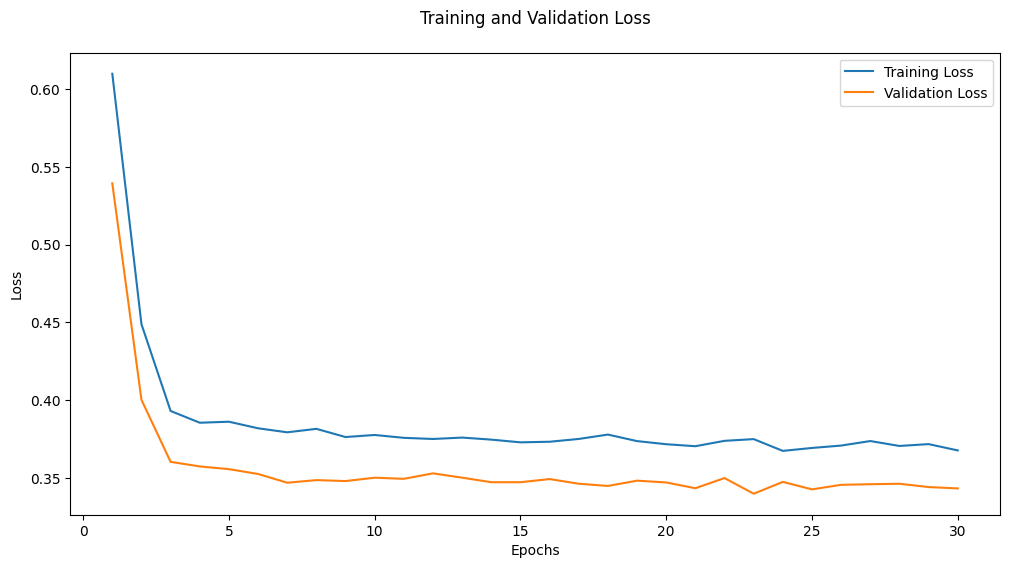

In [134]:
plt.figure(figsize=(12, 6))

train_loss = model_history.history['loss']
val_loss = model_history.history['val_loss']
epochs = range(1, len(train_loss) + 1)

sns.lineplot(x=epochs, y=train_loss, label='Training Loss')
sns.lineplot(x=epochs, y=val_loss, label='Validation Loss')

plt.title('Training and Validation Loss\n')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

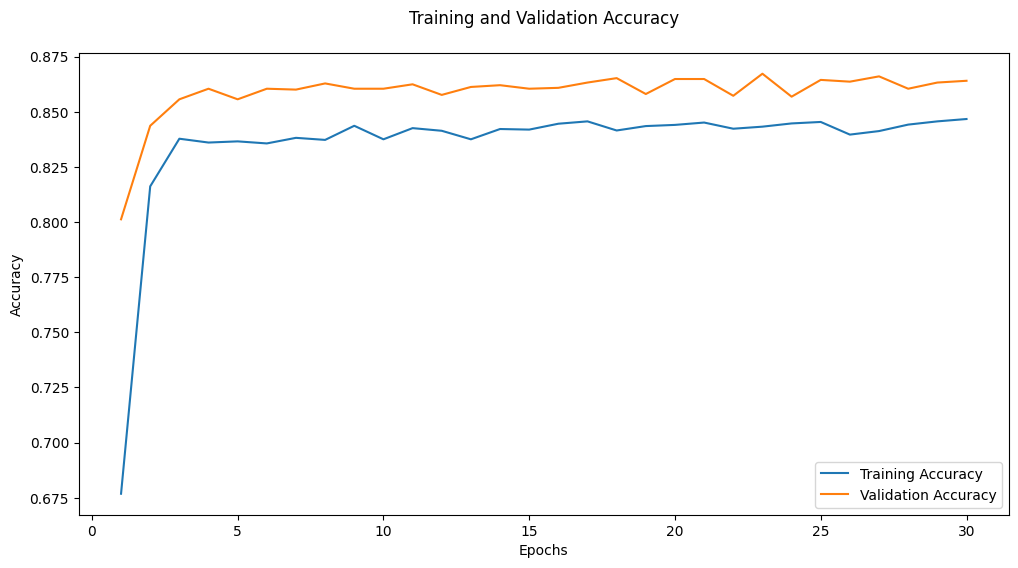

In [135]:
plt.figure(figsize=(12, 6))

train_accuracy = model_history.history['accuracy']
val_accuracy = model_history.history['val_accuracy']
epochs = range(1, len(train_accuracy) + 1)

sns.lineplot(x=epochs, y=train_accuracy, label='Training Accuracy')
sns.lineplot(x=epochs, y=val_accuracy, label='Validation Accuracy')

plt.title('Training and Validation Accuracy\n')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


In [136]:
acc = model.evaluate(x_test, y_test)[1]

print(f'Accuracy of model is {acc}')


79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8640 - loss: 0.3431
Accuracy of model is 0.8640000224113464


In [137]:
model.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_33 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 10)             │            40 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 7)              │            77 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 7)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 7)              │            28 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 2)              │            16 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 747 (2.92 KB)

 Trainable params: 237 (948.00 B)

 Non-trainable params: 34 (136.00 B)

 Optimizer params: 476 (1.86 KB)